In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Load dataset 

In [306]:
df=sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [307]:
df.shape

(344, 7)

In [308]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [309]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


2.Data Preprocessing 

In [310]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

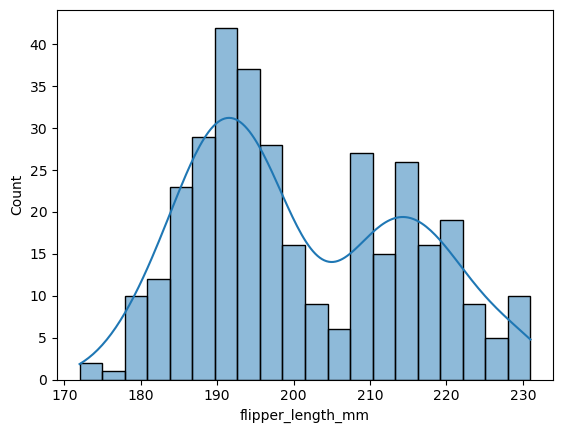

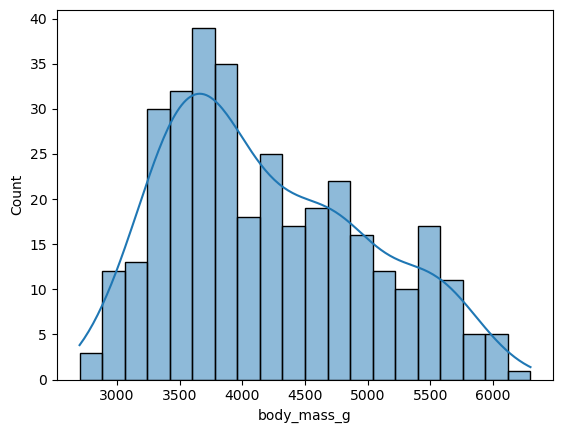

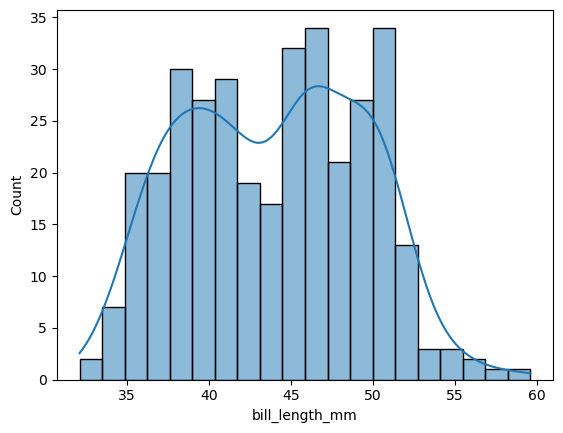

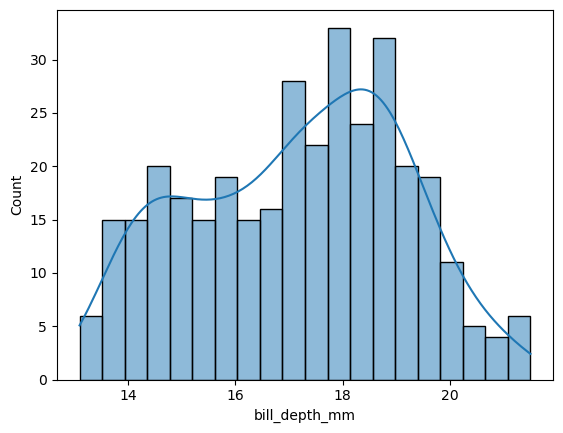

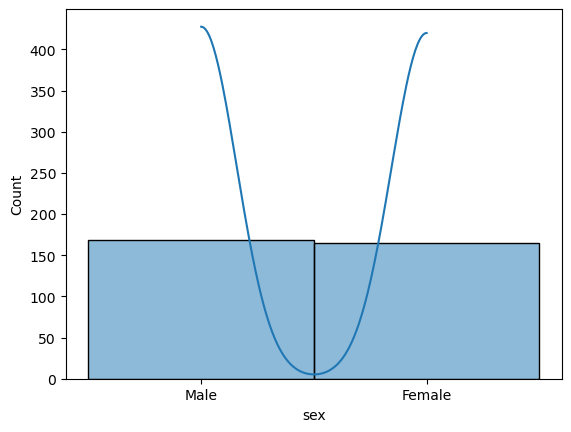

In [311]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = sns.load_dataset("penguins")


sns.histplot(data=df, x="flipper_length_mm", bins=20, kde=True)
plt.show()
sns.histplot(data=df, x="body_mass_g", bins=20, kde=True)
plt.show()
sns.histplot(data=df, x="bill_length_mm", bins=20, kde=True)
plt.show()
sns.histplot(data=df, x="bill_depth_mm", bins=20, kde=True)
plt.show()
sns.histplot(data=df, x="sex", bins=20, kde=True)
plt.show()

In [312]:
df['species']=df['species'].map({'Adelie':0,'Chinstrap':1,'Gentoo':2})

In [313]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col)

island
sex


In [314]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

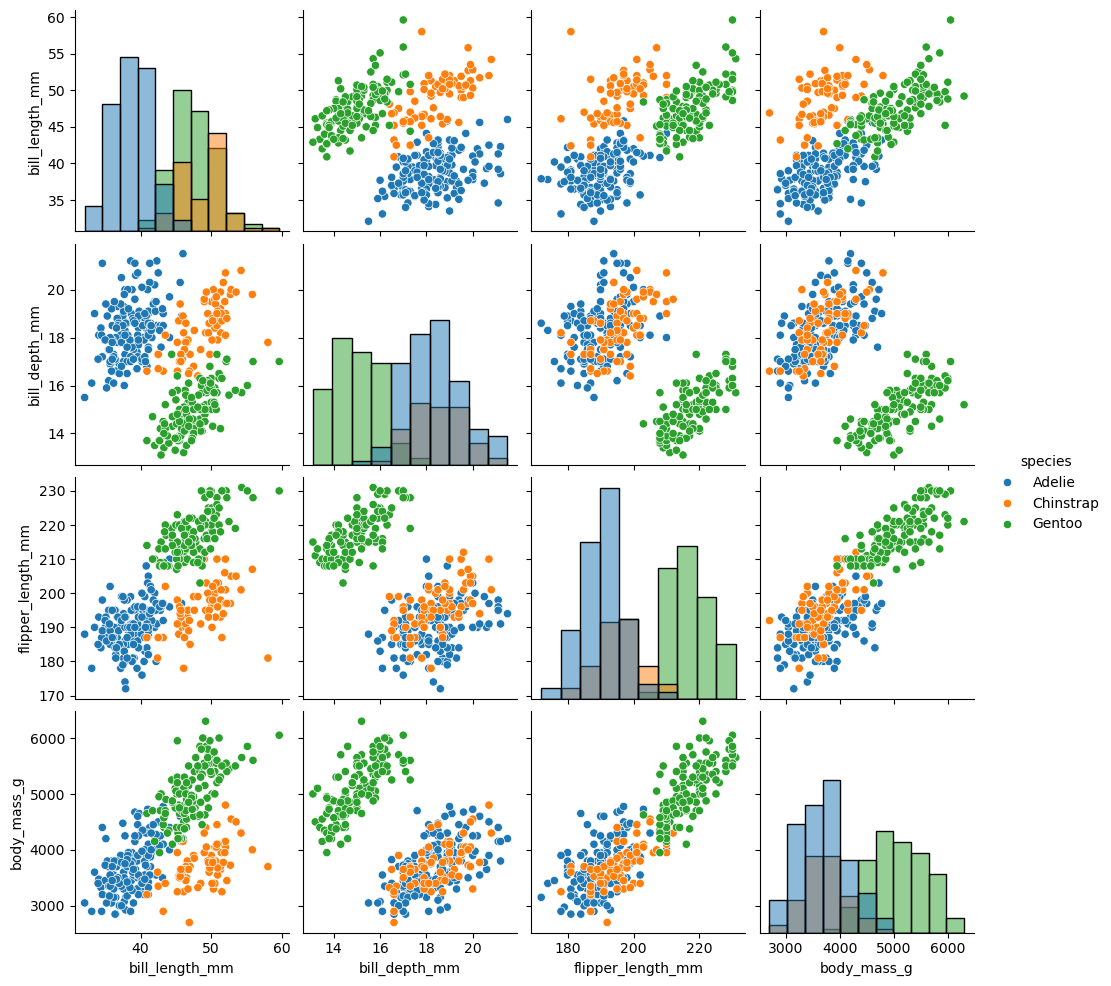

In [315]:
import seaborn as sns
df=sns.load_dataset("penguins")
sns.pairplot(df,hue='species',diag_kind='hist')

In [316]:
from sklearn.preprocessing import StandardScaler
features=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
sc=StandardScaler()
df[features]=sc.fit_transform(df[features])
print(df[features].head())

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       -0.884499       0.785449          -1.418347    -0.564142
1       -0.811126       0.126188          -1.062250    -0.501703
2       -0.664380       0.430462          -0.421277    -1.188532
3             NaN            NaN                NaN          NaN
4       -1.324737       1.089724          -0.563715    -0.938776


In [317]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [318]:
print("DF NaN:")
print(df.isnull().sum())

print("\nX_train NaN:")
print(x_train.isnull().sum())

print("\nTotal NaN in X_train:")
print(x_train.isnull().sum().sum())

DF NaN:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

X_train NaN:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
island_Dream         0
island_Torgersen     0
sex_Male             0
dtype: int64

Total NaN in X_train:
0


In [319]:
df["body_mass_g"] = df["body_mass_g"].fillna(df["body_mass_g"].mean())

df["bill_length_mm"] = df["bill_length_mm"].fillna(df["bill_length_mm"].mean())

df["bill_depth_mm"] = df["bill_depth_mm"].fillna(df["bill_depth_mm"].mean())

df["flipper_length_mm"] = df["flipper_length_mm"].fillna(df["flipper_length_mm"].median())

df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

In [320]:
from sklearn.model_selection import train_test_split
import seaborn as sns
df['species']=df['species'].map({'Adelie':0,'Chinstrap':1,'Gentoo':2})
df = pd.get_dummies(df, columns=['island'], drop_first=True,dtype=int)
df = pd.get_dummies(df, columns=['sex'], drop_first=True,dtype=int)
print(df.head())
print(df.head())
x = df.drop(columns=['species'],axis=1)  
y = df['species']                 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)


   species  bill_length_mm  bill_depth_mm  flipper_length_mm   body_mass_g  \
0        0   -8.844987e-01   7.854492e-01          -1.418347 -5.641421e-01   
1        0   -8.111257e-01   1.261879e-01          -1.062250 -5.017031e-01   
2        0   -6.643797e-01   4.304624e-01          -0.421277 -1.188532e+00   
3        0    8.310441e-17  -1.412775e-15          -0.278838  4.155221e-17   
4        0   -1.324737e+00   1.089724e+00          -0.563715 -9.387762e-01   

   island_Dream  island_Torgersen  sex_Male  
0             0                 1         1  
1             0                 1         0  
2             0                 1         0  
3             0                 1         1  
4             0                 1         0  
   species  bill_length_mm  bill_depth_mm  flipper_length_mm   body_mass_g  \
0        0   -8.844987e-01   7.854492e-01          -1.418347 -5.641421e-01   
1        0   -8.111257e-01   1.261879e-01          -1.062250 -5.017031e-01   
2        0   -6.64379

Train Linear SVM 


3: Linear SVM Model 


In [321]:
from sklearn import svm
C=1   #0.001
svm_clf=svm.SVC(kernel='linear',C=C)
svm_clf.fit(x_train, y_train)


,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [322]:
df.dtypes

species                int64
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
island_Dream           int64
island_Torgersen       int64
sex_Male               int64
dtype: object

In [326]:
y_pred = svm_clf.predict(x_test)
print(y_pred)

[0 0 2 2 1 0 1 2 1 1 0 2 1 2 2 2 0 0 2 2 1 2 2 0 0 0 2 0 2 2 0 0 0 0 0 2 2
 0 0 2 1 0 0 1 0 1 0 0 0 2 0 0 1 0 2 1 0 1 0 2 2 1 2 2 1 2 0 0 2]


In [327]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [329]:
accuracy_score(y_test,y_pred)


1.0

In [330]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [332]:
confusion_matrix(y_test,y_pred)

array([[30,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 25]])

4.Polynomial Kernel SVM

In [333]:
from sklearn import svm
C=1   #0.001
svm_clf=svm.SVC(kernel='poly',degree=3,C=C,gamma='auto')
svm_clf.fit(x_train, y_train)

,C,1
,kernel,'poly'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [334]:
y_pred = svm_clf.predict(x_test)
print(y_pred)

[0 0 2 2 1 0 1 2 1 1 0 2 1 2 2 2 0 0 2 2 1 2 2 0 0 0 2 0 2 2 0 0 0 0 0 2 2
 0 0 2 0 0 0 1 0 1 0 0 0 2 0 0 1 0 2 1 0 1 0 2 2 1 2 2 1 2 0 0 2]


In [335]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [336]:
accuracy_score(y_test,y_pred)

0.9855072463768116

In [337]:
confusion_matrix(y_test,y_pred)

array([[30,  0,  0],
       [ 1, 13,  0],
       [ 0,  0, 25]])

5. RBF Kernel SVM

In [338]:
from sklearn import svm
C=1   #0.001
svm_clf=svm.SVC(kernel='rbf',C=C,gamma=0.1)
svm_clf.fit(x_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [339]:
y_pred = svm_clf.predict(x_test)
print(y_pred)

[0 0 2 2 1 0 1 2 1 1 0 2 1 2 2 2 0 0 2 2 1 2 2 0 0 0 2 0 2 2 0 0 0 0 0 2 2
 0 0 2 1 0 0 1 0 1 0 0 0 2 0 0 1 0 2 1 0 1 0 2 2 1 2 2 1 2 0 0 2]


In [340]:
accuracy_score(y_test,y_pred)

1.0

In [341]:
confusion_matrix(y_test,y_pred)

array([[30,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 25]])

6.Model Comparison

In [359]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

kernels = ['linear', 'poly', 'rbf']
results = []

for k in kernels:
    model = SVC(kernel=k, C=1, random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([k, acc])


In [360]:
# Results table
df_results = pd.DataFrame(results,columns=['Kernel', 'Accuracy'])
print("Kernel Comparison")
print(df_results)

# Best kernel
best_kernel = df_results.loc[df_results['Accuracy'].idxmax(),'Kernel']
best_accuracy = df_results['Accuracy'].max()
print("\nBest Performing Kernel:", best_kernel)
print("Accuracy:", round(best_accuracy*100, 2), "%")

Kernel Comparison
   Kernel  Accuracy
0  linear  1.000000
1    poly  0.985507
2     rbf  1.000000

Best Performing Kernel: linear
Accuracy: 100.0 %


 7.Visualization 

In [348]:
x = df[['bill_length_mm','flipper_length_mm']].dropna()
y = df.dropna()['species']

# Encode target
from sklearn.preprocessing import LabelEncoder, StandardScaler
y = LabelEncoder().fit_transform(y)
scaler = StandardScaler()
x = scaler.fit_transform(x)


In [349]:
# Train SVM
svm_clf = SVC(kernel='linear', C=1)
svm_clf.fit(x, y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [351]:
import numpy as np
import matplotlib.pyplot as plt
# Mesh grid create
x_min, x_max = x_train.iloc[:,0].min()-1, x_train.iloc[:,0].max()+1
y_min, y_max = x_train.iloc[:,1].min()-1, x_train.iloc[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))

In [352]:
# Predict all grid points
Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

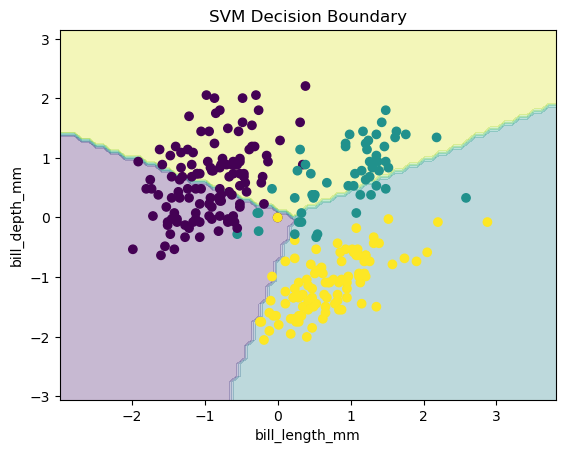

In [356]:
# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)
# Plot training points
plt.scatter(x_train.iloc[:,0],x_train.iloc[:,1],c=y_train)

plt.xlabel(x_train.columns[0])
plt.ylabel(x_train.columns[1])
plt.title("SVM Decision Boundary")
plt.show()

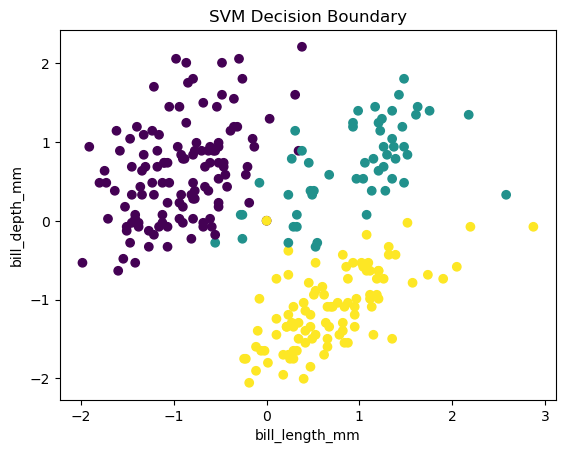

In [355]:
# Plot training points
plt.scatter(x_train.iloc[:,0],x_train.iloc[:,1],c=y_train)

plt.xlabel(x_train.columns[0])
plt.ylabel(x_train.columns[1])
plt.title("SVM Decision Boundary")
plt.show()

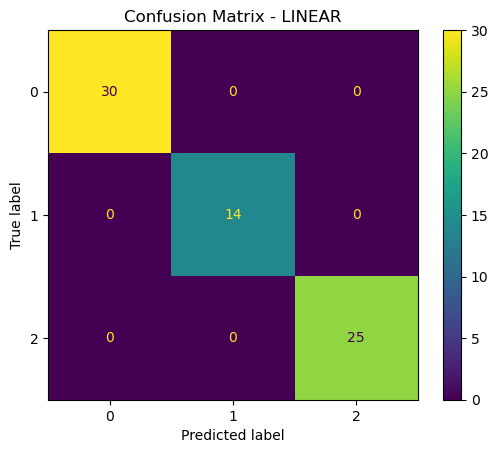

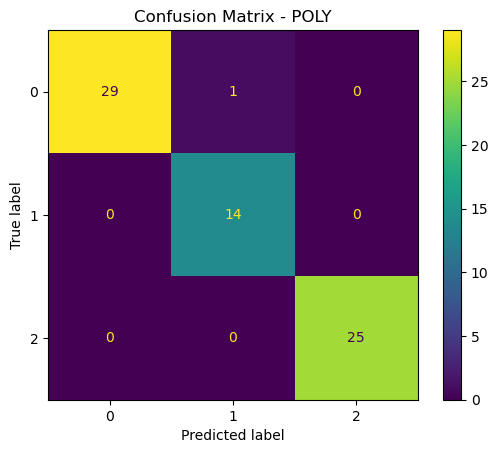

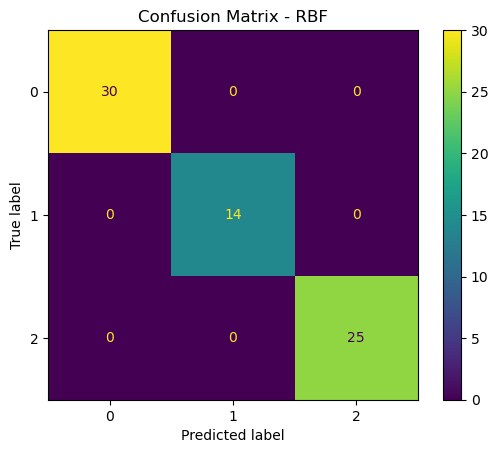

In [363]:
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

kernels = ['linear', 'poly', 'rbf']
for k in kernels:

    model = SVC(kernel=k, random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
    plt.title(f'Confusion Matrix - {k.upper()}')
    plt.show()